Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/raw/netflix_customer_churn.csv")

In [4]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [5]:
df.shape

(5000, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 920.1

In [7]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [8]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["churned"].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

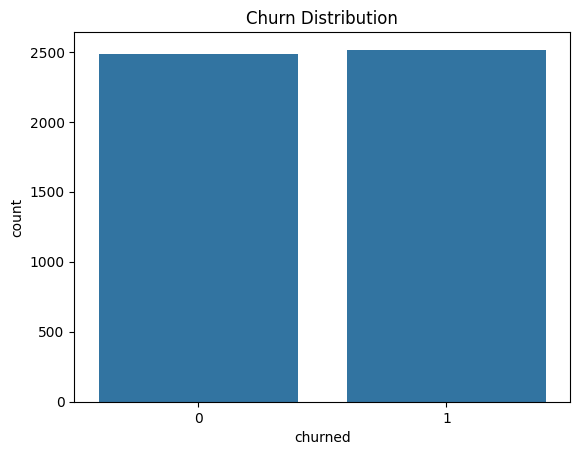

In [11]:
sns.countplot(x="churned", data=df)

plt.title("Churn Distribution")
plt.show()

Understad Column Type

In [12]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['customer_id', 'gender', 'subscription_type', 'region', 'device',
       'payment_method', 'favorite_genre'],
      dtype='str')

Numerical Columns:
Index(['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'churned',
       'number_of_profiles', 'avg_watch_time_per_day'],
      dtype='str')


Exploratory Data Analysis :-

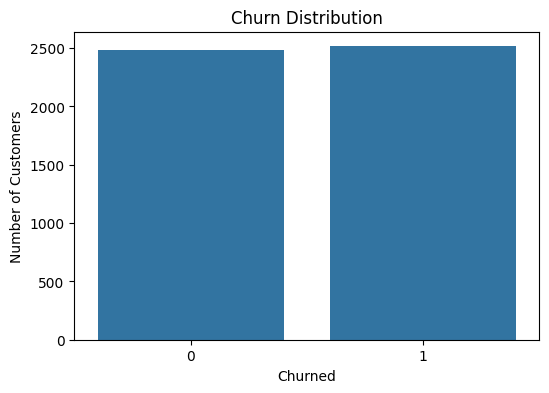

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='churned', data=df)

plt.title("Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

plt.show()

Churn Distribution

In [14]:
churn_percentage = df["churned"].value_counts(normalize=True) * 100

print(churn_percentage)

churned
1    50.3
0    49.7
Name: proportion, dtype: float64


Subscription Type vs Churn

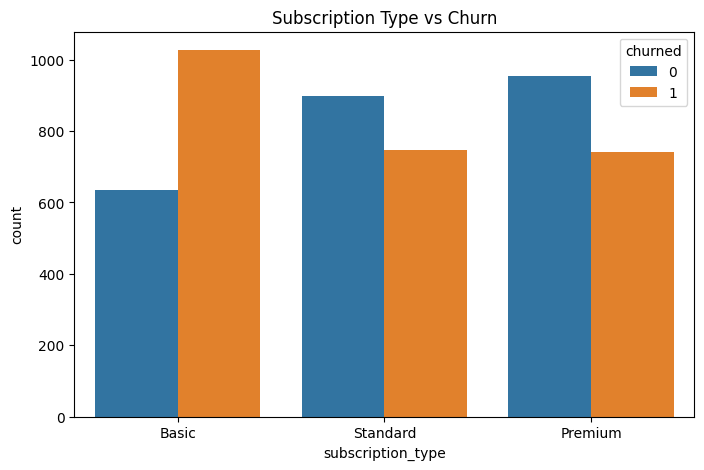

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='subscription_type',
    hue='churned',
    data=df
)

plt.title("Subscription Type vs Churn")

plt.show()

Watch hour distribution

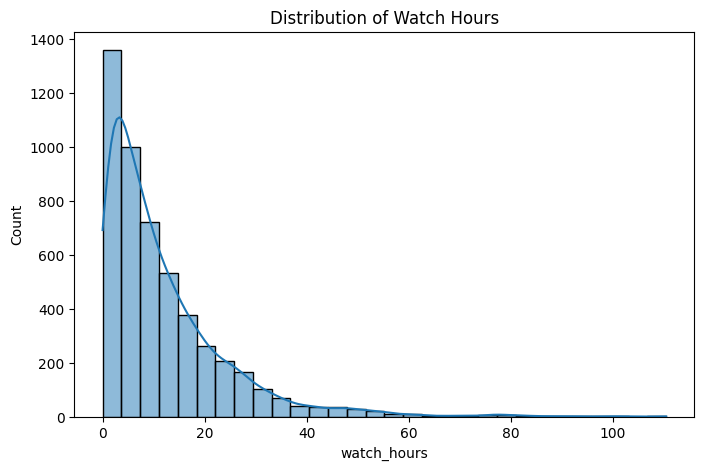

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['watch_hours'],
    bins=30,
    kde=True
)

plt.title("Distribution of Watch Hours")

plt.show()

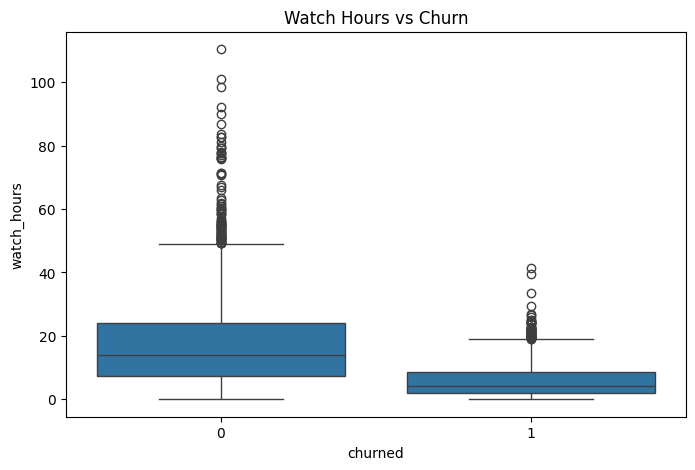

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churned',
    y='watch_hours',
    data=df
)

plt.title("Watch Hours vs Churn")

plt.show()

Last Login Day vs Churn

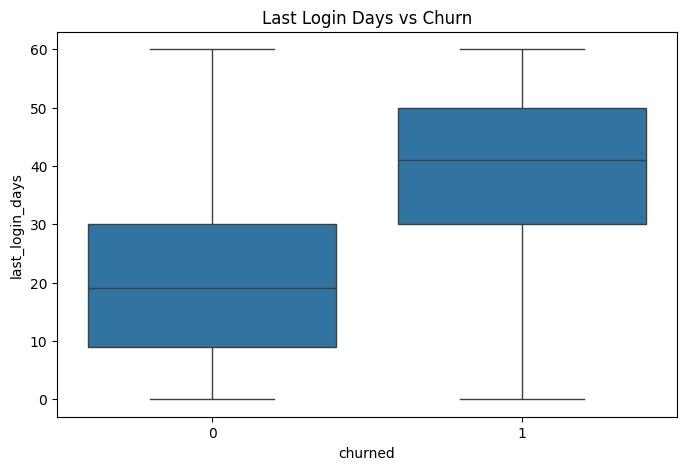

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churned',
    y='last_login_days',
    data=df
)

plt.title("Last Login Days vs Churn")

plt.show()

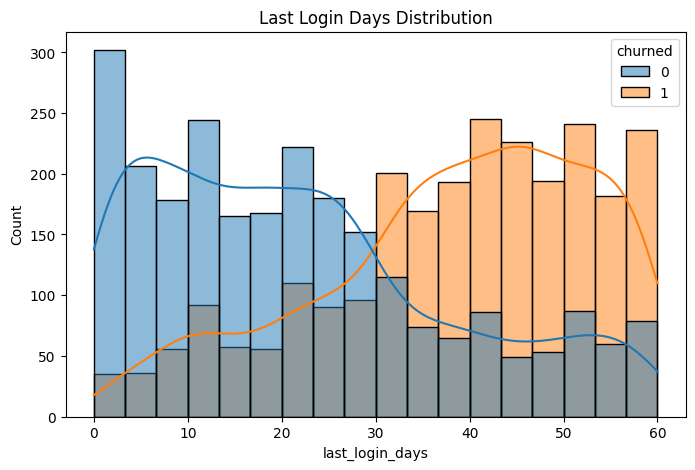

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='last_login_days',
    hue='churned',
    kde=True
)

plt.title("Last Login Days Distribution")

plt.show()

Region-wise Churn

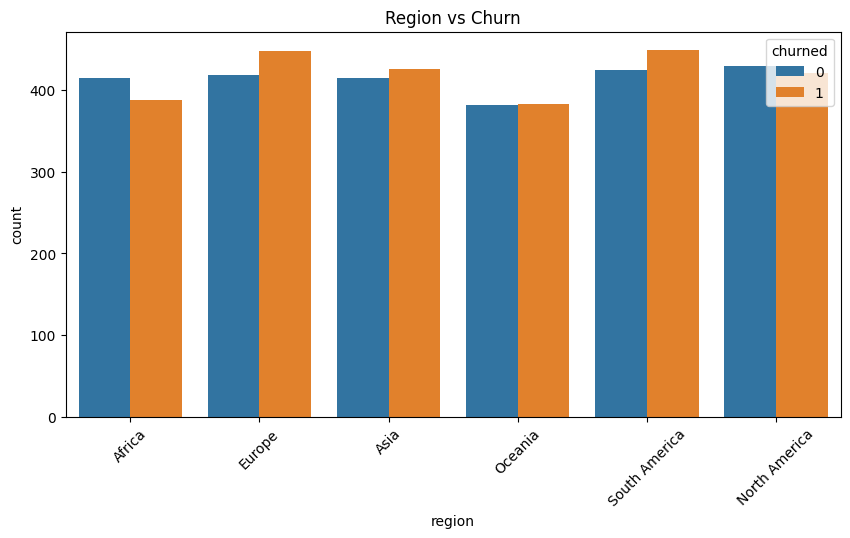

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='region',
    hue='churned',
    data=df
)

plt.title("Region vs Churn")

plt.xticks(rotation=45)

plt.show()

Device-wise Churn

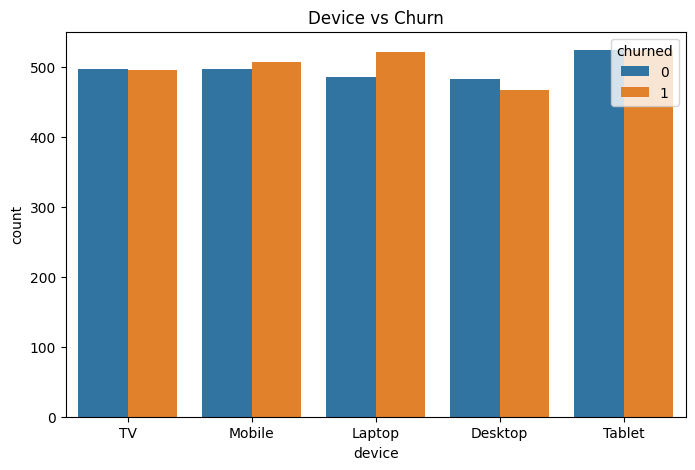

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='device',
    hue='churned',
    data=df
)

plt.title("Device vs Churn")

plt.show()

Genre-wwise Churn

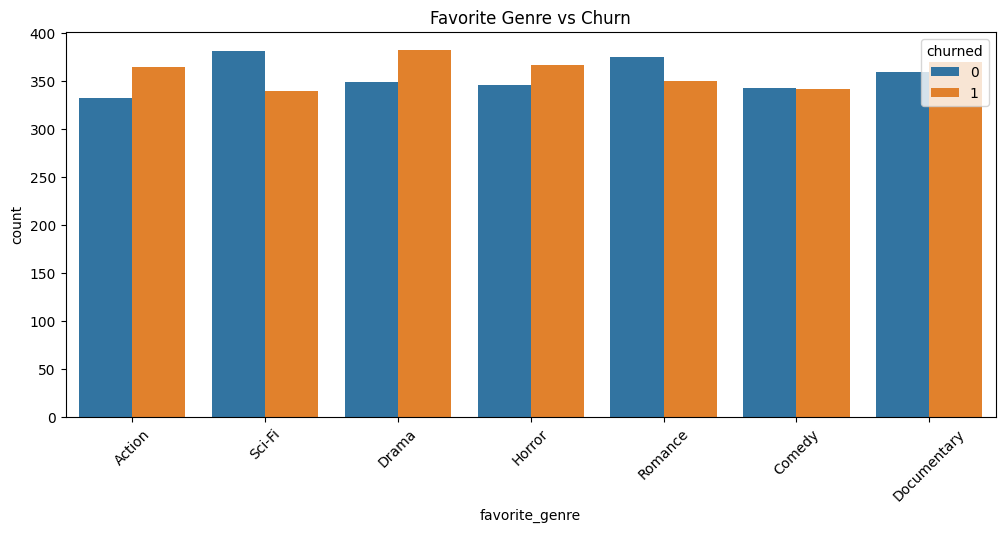

In [22]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='favorite_genre',
    hue='churned',
    data=df
)

plt.title("Favorite Genre vs Churn")

plt.xticks(rotation=45)

plt.show()

Correlation Heatmap

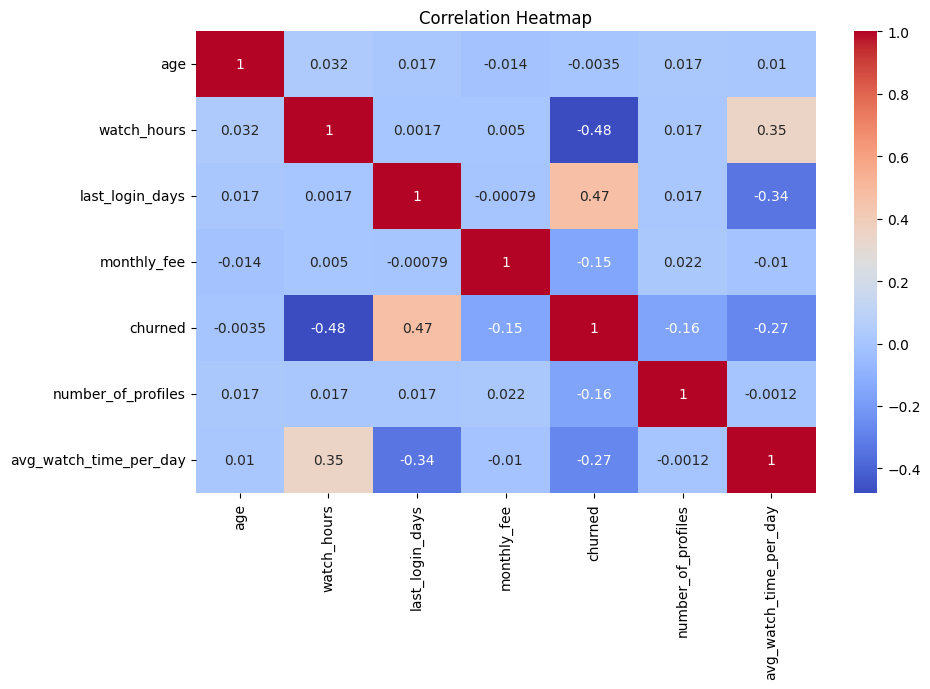

In [23]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Feature 1 - Engagement Score

In [24]:
df["engagement_score"] = (
    df["watch_hours"]
    + df["avg_watch_time_per_day"]
    - df["last_login_days"]
)

In [25]:
df[[
    "watch_hours",
    "avg_watch_time_per_day",
    "last_login_days",
    "engagement_score"
]].head()

,watch_hours,avg_watch_time_per_day,last_login_days,engagement_score
0,14.73,0.49,29,-13.78
1,0.70,0.03,19,-18.27
2,16.32,1.48,10,7.80
3,4.51,0.35,12,-7.14
4,1.89,0.13,13,-10.98


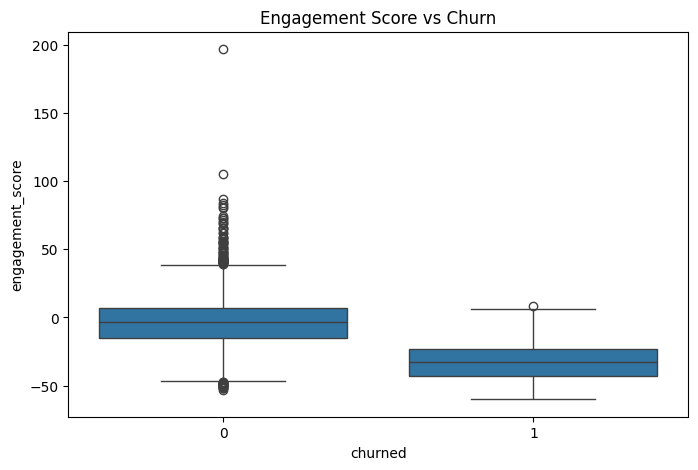

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="churned",
    y="engagement_score",
    data=df
)

plt.title("Engagement Score vs Churn")

plt.show()

Create ML DataFrame

In [27]:
df_ml = df.drop("customer_id", axis=1)

df_ml.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,engagement_score
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,-13.78
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,-18.27
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,7.80
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,-7.14
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,-10.98


In [28]:
df_ml["churned"].value_counts(normalize=True)*100

churned
1    50.3
0    49.7
Name: proportion, dtype: float64

Seperate Feature and Target

In [29]:
X = df_ml.drop("churned", axis=1)

y = df_ml["churned"]

Identify Categorical Columns

In [30]:
categorical_cols = X.select_dtypes(include="object").columns

print(categorical_cols)

Index(['gender', 'subscription_type', 'region', 'device', 'payment_method',
       'favorite_genre'],
      dtype='str')


Using One-Hot Encoding - as label encoding may confuse the model 

In [31]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X_encoded.head()

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day,engagement_score,gender_Male,gender_Other,subscription_type_Premium,...,payment_method_Crypto,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
0,51,14.73,29,8.99,1,0.49,-13.78,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,47,0.70,19,13.99,5,0.03,-18.27,False,True,False,...,False,False,True,False,False,False,False,False,False,True
2,27,16.32,10,13.99,2,1.48,7.80,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,53,4.51,12,17.99,2,0.35,-7.14,False,True,True,...,True,False,False,False,False,False,False,True,False,False
4,56,1.89,13,13.99,2,0.13,-10.98,False,True,False,...,True,False,False,False,False,False,False,False,False,False


In [32]:
print("Original Shape:", X.shape)
print("Encoded Shape:", X_encoded.shape)

Original Shape: (5000, 13)
Encoded Shape: (5000, 30)


In [33]:
X_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   watch_hours                 5000 non-null   float64
 2   last_login_days             5000 non-null   int64  
 3   monthly_fee                 5000 non-null   float64
 4   number_of_profiles          5000 non-null   int64  
 5   avg_watch_time_per_day      5000 non-null   float64
 6   engagement_score            5000 non-null   float64
 7   gender_Male                 5000 non-null   bool   
 8   gender_Other                5000 non-null   bool   
 9   subscription_type_Premium   5000 non-null   bool   
 10  subscription_type_Standard  5000 non-null   bool   
 11  region_Asia                 5000 non-null   bool   
 12  region_Europe               5000 non-null   bool   
 13  region_North America        5000 non-null   

In [34]:
bool_cols = X_encoded.select_dtypes(include='bool').columns

X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

In [35]:
X_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   watch_hours                 5000 non-null   float64
 2   last_login_days             5000 non-null   int64  
 3   monthly_fee                 5000 non-null   float64
 4   number_of_profiles          5000 non-null   int64  
 5   avg_watch_time_per_day      5000 non-null   float64
 6   engagement_score            5000 non-null   float64
 7   gender_Male                 5000 non-null   int64  
 8   gender_Other                5000 non-null   int64  
 9   subscription_type_Premium   5000 non-null   int64  
 10  subscription_type_Standard  5000 non-null   int64  
 11  region_Asia                 5000 non-null   int64  
 12  region_Europe               5000 non-null   int64  
 13  region_North America        5000 non-null   

In [62]:
encoded_df = X_encoded.copy()

encoded_df["churned"] = y

encoded_df.to_csv(
    "../data/processed/final_dataset_encoded.csv",
    index=False
)

print("Encoded dataset saved successfully!")

Encoded dataset saved successfully!


Train-test split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Verify Shapes

In [37]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 30)
X_test: (1000, 30)
y_train: (4000,)
y_test: (1000,)


Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Baseline Model - Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Prediction

In [40]:
y_pred = lr_model.predict(X_test_scaled)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.887

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.87      0.88       497
           1       0.88      0.90      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



Confusion Matrix

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[432  65]
 [ 48 455]]


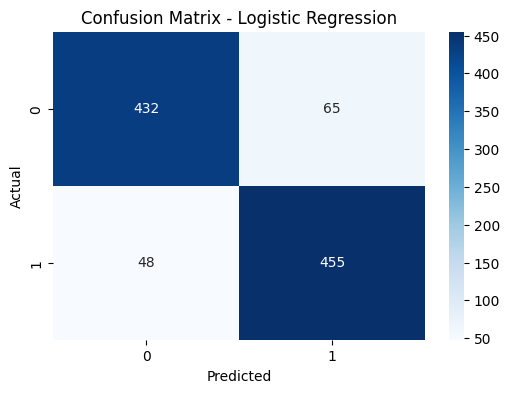

In [43]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

Decision Tree

In [44]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

y_pred_dt = dt_model.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(
    y_test,
    y_pred_dt
))

Accuracy: 0.978
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       497
           1       0.97      0.98      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

print(cm_dt)

[[483  14]
 [  8 495]]


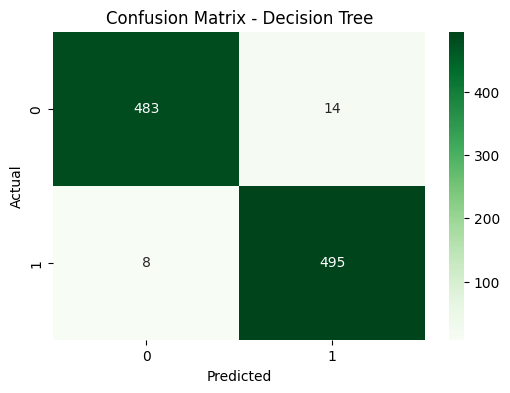

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       497
           1       0.97      0.98      0.98       503

    accuracy                           0.97      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.98      0.97      0.97      1000



In [50]:
feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf.head(15)

,Feature,Importance
5,avg_watch_time_per_day,0.260057
6,engagement_score,0.239989
1,watch_hours,0.173086
2,last_login_days,0.106635
4,number_of_profiles,0.060579
3,monthly_fee,0.028142
0,age,0.021164
20,payment_method_Crypto,0.016430
22,payment_method_Gift Card,0.013686
10,subscription_type_Standard,0.007770


In [51]:
print(y_pred_rf[:10])
print(y_pred_dt[:10])

print((y_pred_rf == y_pred_dt).all())

[0 1 1 1 1 1 1 1 0 0]
[0 1 0 1 1 1 1 1 0 0]
False


In [52]:
rf_model.score(X_train, y_train)

1.0

In [53]:
dt_model.score(X_train, y_train)

1.0

In [54]:
feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
5,avg_watch_time_per_day,0.260057
6,engagement_score,0.239989
1,watch_hours,0.173086
2,last_login_days,0.106635
4,number_of_profiles,0.060579
3,monthly_fee,0.028142
0,age,0.021164
20,payment_method_Crypto,0.016430
22,payment_method_Gift Card,0.013686
10,subscription_type_Standard,0.007770


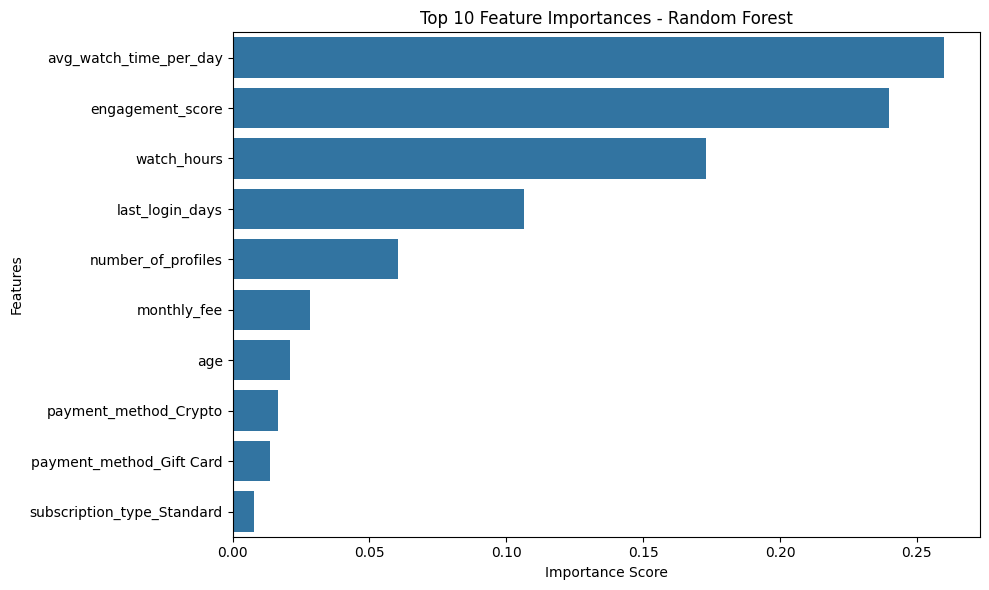

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [56]:
import joblib

joblib.dump(
    rf_model,
    "../models/trained_model.pkl"
)

['../models/trained_model.pkl']

In [57]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [58]:
df.to_csv(
    "../data/processed/final_dataset.csv",
    index=False
)

In [59]:
plt.savefig(
    "../visualizations/feature_importance.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Model Comparison

In [60]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.887,
        0.975,
        0.975
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.887
1,Decision Tree,0.975
2,Random Forest,0.975


In [61]:
print(df.columns)

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre', 'engagement_score'],
      dtype='str')


Saving Training columns

In [63]:
import joblib

joblib.dump(
    X_encoded.columns.tolist(),
    "../models/feature_columns.pkl"
)

print("Feature columns saved!")

Feature columns saved!


Some Analysis 

In [65]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre', 'engagement_score'],
      dtype='str')

In [67]:
print(df["churned"].value_counts())

churned
1    2515
0    2485
Name: count, dtype: int64


In [68]:
print(df["churned"].value_counts(normalize=True))

churned
1    0.503
0    0.497
Name: proportion, dtype: float64


In [69]:
df["churned"]

0       1
1       1
2       0
3       1
4       1
       ..
4995    0
4996    0
4997    1
4998    0
4999    1
Name: churned, Length: 5000, dtype: int64

In [70]:
import numpy as np

probs = rf_model.predict_proba(X_test)[:,1]

print("Min:", probs.min())
print("Max:", probs.max())

print("\nProbability Distribution")

print("0-10% :", np.sum(probs <= 0.10))
print("10-30%:", np.sum((probs > 0.10) & (probs <= 0.30)))
print("30-70%:", np.sum((probs > 0.30) & (probs <= 0.70)))
print("70-90%:", np.sum((probs > 0.70) & (probs <= 0.90)))
print("90-100%:", np.sum(probs > 0.90))

Min: 0.0
Max: 1.0

Probability Distribution
0-10% : 349
10-30%: 105
30-70%: 85
70-90%: 108
90-100%: 353
